In [52]:
import requests
import pandas as pd
import numpy as np
from binance.client import Client
import datetime
from itertools import combinations
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import matplotlib.pyplot as plt
from arch import arch_model

In [53]:
def kalman_hedge_ratio(series_x: pd.Series, series_y: pd.Series, delta: float = 1e-4, obs_var: float = 1.0):
    idx = series_x.index.intersection(series_y.index)
    x = series_x.loc[idx].astype(float)
    y = series_y.loc[idx].astype(float)

    state_mean = np.zeros(2, dtype=float)
    state_cov = np.eye(2, dtype=float)
    Q = (delta / max(1e-12, 1.0 - delta)) * np.eye(2, dtype=float)
    R = float(obs_var)

    alpha = np.zeros(len(idx), dtype=float)
    beta = np.zeros(len(idx), dtype=float)

    for i, (xt, yt) in enumerate(zip(x.values, y.values)):
        H = np.array([[1.0, xt]], dtype=float)
        state_mean_pred = state_mean
        state_cov_pred = state_cov + Q

        y_pred = float(H @ state_mean_pred)
        err = yt - y_pred
        S = float(H @ state_cov_pred @ H.T + R)
        K = (state_cov_pred @ H.T) / S

        state_mean = state_mean_pred + (K.flatten() * err)
        state_cov = (np.eye(2) - K @ H) @ state_cov_pred

        alpha[i] = state_mean[0]
        beta[i] = state_mean[1]

    alpha_s = pd.Series(alpha, index=idx, name="alpha")
    beta_s = pd.Series(beta, index=idx, name="beta")
    spread = y - (alpha_s + beta_s * x)

    adf = adfuller(spread.dropna()) if spread.dropna().shape[0] >= 20 else [np.nan, np.nan, None, None, {"1%": np.nan, "5%": np.nan, "10%": np.nan}]
    return {
        "alpha_series": alpha_s,
        "beta_series": beta_s,
        "latest_alpha": float(alpha_s.iloc[-1]),
        "latest_beta": float(beta_s.iloc[-1]),
        "spread": spread,
        "pvalue": adf[1],
        "t_stat": adf[0],
        "crit_1%": adf[4]["1%"],
        "crit_5%": adf[4]["5%"],
        "crit_10%": adf[4]["10%"],
    }

def fit_ou_from_spread(spread: pd.Series, dt: float = 1.0):
    s = spread.dropna().astype(float)
    if len(s) < 30:
        return None

    s_t = s.iloc[:-1].values
    s_t1 = s.iloc[1:].values
    X = sm.add_constant(s_t)
    res = sm.OLS(s_t1, X).fit()

    b = float(res.params[0])
    a = float(res.params[1])

    if not (0 < a < 1):
        return None

    kappa = -np.log(a) / dt
    mu = b / (1 - a)
    resid = res.resid
    sigma_eq = np.std(resid, ddof=1) / np.sqrt(max(1e-12, 1 - a**2))
    half_life = np.log(2) / kappa if kappa > 0 else np.inf

    if not np.isfinite(mu) or not np.isfinite(sigma_eq) or sigma_eq <= 0:
        return None

    return {
        "mu": float(mu),
        "sigma": float(sigma_eq),
        "half_life": float(half_life),
        "kappa": float(kappa),
        "a": a,
        "b": b,
    }

def ou_zscore(spread: pd.Series, mu: float, sigma: float):
    sigma = max(float(sigma), 1e-12)
    return (spread - float(mu)) / sigma

def zscore_signals(z: pd.Series, entry_z: float = 2.0, exit_z: float = 0.5, min_hold: int = 8, stop_z: float = None):
    z = z.astype(float)
    sig = pd.Series(0, index=z.index, dtype=int)
    pos = 0
    held = 0

    for i, val in enumerate(z.values):
        if pos == 0:
            if val >= entry_z:
                pos = -1
                held = 0
            elif val <= -entry_z:
                pos = 1
                held = 0
        else:
            held += 1
            exit_cond = (abs(val) <= exit_z and held >= min_hold)
            stop_cond = (stop_z is not None and abs(val) >= stop_z)
            if exit_cond or stop_cond:
                pos = 0
                held = 0
        sig.iloc[i] = pos
    return sig

def _max_drawdown(equity: pd.Series) -> float:
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min()) if len(dd) else np.nan

def _sharpe(returns: pd.Series, bars_per_year: int) -> float:
    r = returns.dropna()
    if len(r) < 2 or float(r.std(ddof=1)) == 0:
        return np.nan
    return float((r.mean() / r.std(ddof=1)) * np.sqrt(bars_per_year))

def _trade_stats(signal: pd.Series, pnl: pd.Series):
    changes = signal.fillna(0).astype(int).diff().fillna(0)
    entries = changes[changes != 0].index
    num_trades = int(((changes != 0) & (signal != 0)).sum())
    wins = 0
    losses = 0
    current = None
    trade_pnl = 0.0
    prev_sig = 0
    for ts, sig in signal.items():
        s = int(sig)
        p = float(pnl.loc[ts]) if ts in pnl.index else 0.0
        if prev_sig == 0 and s != 0:
            current = s
            trade_pnl = p
        elif prev_sig != 0:
            trade_pnl += p
            if s == 0 or s != prev_sig:
                if trade_pnl > 0:
                    wins += 1
                else:
                    losses += 1
                current = None
                trade_pnl = 0.0
        prev_sig = s
    total = wins + losses
    return {"num_trades": total, "win_rate": wins / total if total else np.nan}

def backtest_pair_perps(prices, x, y, beta, signal, initial_capital=10000.0, leverage=3.0, alloc=1.0, fee_rate=0.0004, slippage_bps=1.0, bars_per_year=365*24*4):
    px = prices[x].astype(float).rename("px")
    py = prices[y].astype(float).rename("py")
    sig = signal.astype(int).rename("sig")

    if isinstance(beta, pd.Series):
        beta_s = beta.astype(float).rename("beta")
        df = pd.concat([px, py, sig, beta_s], axis=1).dropna().copy()
    else:
        df = pd.concat([px, py, sig], axis=1).dropna().copy()
        df["beta"] = float(beta)

    if len(df) < 5:
        return {"pair": f"{x}-{y}", "df": df, "stats": {"error": "not enough data"}}

    df["sig_exec"] = df["sig"].shift(1).fillna(0).astype(int)

    equity = np.zeros(len(df))
    pnl = np.zeros(len(df))
    fees = np.zeros(len(df))
    ux = np.zeros(len(df))
    uy = np.zeros(len(df))

    equity[0] = initial_capital
    prev_ux = prev_uy = 0.0

    for i in range(1, len(df)):
        px_prev, py_prev = float(df["px"].iloc[i-1]), float(df["py"].iloc[i-1])
        px_now, py_now = float(df["px"].iloc[i]), float(df["py"].iloc[i])
        beta_now = float(df["beta"].iloc[i])
        sig_now = int(df["sig_exec"].iloc[i])

        mtm = prev_ux * (px_now - px_prev) + prev_uy * (py_now - py_prev)
        pnl[i] = mtm
        equity[i] = equity[i-1] + mtm

        gross = max(equity[i], 0.0) * float(alloc) * float(leverage)
        w_x = abs(beta_now)
        w_y = 1.0
        denom = w_x + w_y if (w_x + w_y) != 0 else 1.0
        nx = gross * w_x / denom
        ny = gross * w_y / denom

        if sig_now == 0:
            tgt_ux, tgt_uy = 0.0, 0.0
        elif sig_now == 1:
            tgt_uy = +(ny / py_now)
            tgt_ux = -np.sign(beta_now) * (nx / px_now)
        else:
            tgt_uy = -(ny / py_now)
            tgt_ux = +np.sign(beta_now) * (nx / px_now)

        dx = tgt_ux - prev_ux
        dy = tgt_uy - prev_uy
        traded_notional = abs(dx) * px_now + abs(dy) * py_now
        fees[i] = traded_notional * (fee_rate + slippage_bps / 10000.0)
        equity[i] -= fees[i]

        ux[i], uy[i] = tgt_ux, tgt_uy
        prev_ux, prev_uy = tgt_ux, tgt_uy

    out = df.copy()
    out["ux"] = ux
    out["uy"] = uy
    out["pnl"] = pnl
    out["fees"] = fees
    out["equity"] = equity
    out["ret"] = out["equity"].pct_change().fillna(0.0)
    out["turnover"] = ((out["ux"].diff().abs() * out["px"]) + (out["uy"].diff().abs() * out["py"])).fillna(0.0) / out["equity"].replace(0, np.nan)

    stats = {
        "pair": f"{x}-{y}",
        "beta": float(out["beta"].iloc[-1]),
        "initial_capital": float(initial_capital),
        "final_equity": float(out["equity"].iloc[-1]),
        "total_pnl": float(out["pnl"].sum() - out["fees"].sum()),
        "gross_pnl": float(out["pnl"].sum()),
        "total_fees": float(out["fees"].sum()),
        "sharpe": _sharpe(out["ret"], bars_per_year),
        "max_drawdown": _max_drawdown(out["equity"]),
        "avg_turnover": float(out["turnover"].replace([np.inf, -np.inf], np.nan).dropna().mean()) if out["turnover"].notna().any() else np.nan,
    }
    stats.update(_trade_stats(out["sig_exec"], out["pnl"] - out["fees"]))
    return {"pair": f"{x}-{y}", "df": out, "stats": stats}

def optimize_train_parameters(train_prices, x, y, entry_grid=(1.5,2.0,2.5), exit_grid=(0.0,0.5,1.0), min_hold_grid=(8,16), delta_grid=(1e-4,), stop_z=4.0, pvalue_threshold=0.10, max_halflife=24*4*2, bars_per_year=365*24*4):
    best = None
    evaluations = []

    lx = np.log(train_prices[x].astype(float))
    ly = np.log(train_prices[y].astype(float))

    for delta in delta_grid:
        kf = kalman_hedge_ratio(lx, ly, delta=delta)
        spread_train = kf["spread"].dropna()
        if len(spread_train) < 50:
            continue
        adf = adfuller(spread_train)
        pvalue = adf[1]
        ou = fit_ou_from_spread(spread_train)
        if ou is None:
            continue
        if pvalue > pvalue_threshold or not (0 < ou["half_life"] < max_halflife):
            continue

        for entry_z in entry_grid:
            for exit_z in exit_grid:
                if exit_z >= entry_z:
                    continue
                for min_hold in min_hold_grid:
                    z_train = ou_zscore(spread_train, ou["mu"], ou["sigma"])
                    sig_train = zscore_signals(z_train, entry_z=entry_z, exit_z=exit_z, min_hold=min_hold, stop_z=stop_z)
                    bt = backtest_pair_perps(
                        prices=train_prices.loc[sig_train.index, [x, y]],
                        x=x, y=y,
                        beta=kf["beta_series"].loc[sig_train.index],
                        signal=sig_train,
                        initial_capital=10000.0,
                        leverage=3.0,
                        alloc=1.0,
                        fee_rate=0.0004,
                        slippage_bps=1.0,
                        bars_per_year=bars_per_year,
                    )
                    stats = bt["stats"]
                    num_trades = stats.get("num_trades", 0)
                    sharpe = stats.get("sharpe", np.nan)
                    total_pnl = stats.get("total_pnl", -np.inf)
                    score = (-np.inf if pd.isna(sharpe) else sharpe) + 0.00001 * total_pnl
                    rec = {
                        "delta": delta,
                        "entry_z": entry_z,
                        "exit_z": exit_z,
                        "min_hold": min_hold,
                        "pvalue": pvalue,
                        "half_life": ou["half_life"],
                        "mu": ou["mu"],
                        "sigma": ou["sigma"],
                        "alpha_last": kf["latest_alpha"],
                        "beta_last": kf["latest_beta"],
                        "train_sharpe": sharpe,
                        "train_total_pnl": total_pnl,
                        "train_num_trades": num_trades,
                        "score": score,
                    }
                    evaluations.append(rec)
                    if num_trades < 2:
                        continue
                    if best is None or rec["score"] > best["score"]:
                        best = rec

    eval_df = pd.DataFrame(evaluations).sort_values(["score", "train_total_pnl"], ascending=False) if evaluations else pd.DataFrame()
    return best, eval_df

def walk_forward_optimize_pair(prices, x="BTC", y="ETH", train_window=24*4*25, test_window=24*4, step=None, entry_grid=(1.5,2.0,2.5), exit_grid=(0.0,0.5,1.0), min_hold_grid=(8,16), delta_grid=(1e-4,), stop_z=4.0, pvalue_threshold=0.10, max_halflife=24*4*2, bars_per_year=365*24*4):
    step = test_window if step is None else step
    prices = prices[[x, y]].dropna().copy()

    all_signals = []
    all_z = []
    all_beta = []
    window_summaries = []

    for start in range(train_window, len(prices) - test_window + 1, step):
        train = prices.iloc[start-train_window:start].copy()
        test = prices.iloc[start:start+test_window].copy()

        best, eval_df = optimize_train_parameters(
            train_prices=train, x=x, y=y,
            entry_grid=entry_grid, exit_grid=exit_grid, min_hold_grid=min_hold_grid,
            delta_grid=delta_grid, stop_z=stop_z, pvalue_threshold=pvalue_threshold,
            max_halflife=max_halflife, bars_per_year=bars_per_year
        )
        if best is None:
            window_summaries.append({
                "train_start": train.index[0], "train_end": train.index[-1],
                "test_start": test.index[0], "test_end": test.index[-1],
                "status": "skipped_no_valid_params",
            })
            continue

        lx_test = np.log(test[x].astype(float))
        ly_test = np.log(test[y].astype(float))
        beta_test = pd.Series(best["beta_last"], index=test.index, name="beta")
        spread_test = ly_test - (best["alpha_last"] + best["beta_last"] * lx_test)
        z_test = ou_zscore(spread_test, best["mu"], best["sigma"])
        sig_test = zscore_signals(
            z_test,
            entry_z=best["entry_z"],
            exit_z=best["exit_z"],
            min_hold=int(best["min_hold"]),
            stop_z=stop_z,
        )

        all_signals.append(sig_test)
        all_z.append(z_test.rename("zscore"))
        all_beta.append(beta_test)

        bt_test = backtest_pair_perps(
            prices=test, x=x, y=y,
            beta=beta_test, signal=sig_test,
            initial_capital=10000.0, leverage=3.0, alloc=1.0,
            fee_rate=0.0004, slippage_bps=1.0, bars_per_year=bars_per_year,
        )
        window_summaries.append({
            "train_start": train.index[0], "train_end": train.index[-1],
            "test_start": test.index[0], "test_end": test.index[-1],
            "status": "traded",
            "entry_z": best["entry_z"],
            "exit_z": best["exit_z"],
            "min_hold": int(best["min_hold"]),
            "delta": best["delta"],
            "train_sharpe": best["train_sharpe"],
            "train_total_pnl": best["train_total_pnl"],
            "test_sharpe": bt_test["stats"].get("sharpe", np.nan),
            "test_total_pnl": bt_test["stats"].get("total_pnl", np.nan),
            "test_num_trades": bt_test["stats"].get("num_trades", np.nan),
        })

    if not all_signals:
        return {
            "pair": f"{x}-{y}",
            "signal": pd.Series(dtype=int),
            "z_scores": pd.Series(dtype=float),
            "beta": pd.Series(dtype=float),
            "window_summary": pd.DataFrame(window_summaries),
            "backtest": None,
        }

    signal = pd.concat(all_signals).sort_index()
    z_scores = pd.concat(all_z).sort_index()
    beta = pd.concat(all_beta).sort_index()

    final_bt = backtest_pair_perps(prices=prices, x=x, y=y, beta=beta, signal=signal, initial_capital=10000.0, leverage=3.0, alloc=1.0, fee_rate=0.0004, slippage_bps=1.0, bars_per_year=bars_per_year)
    return {
        "pair": f"{x}-{y}",
        "signal": signal,
        "z_scores": z_scores,
        "beta": beta,
        "window_summary": pd.DataFrame(window_summaries),
        "backtest": final_bt,
    }

def run_btc_pair_universe(prices, anchor="BTC", train_window=24*4*25, test_window=24*4, step=None, entry_grid=(1.5,2.0,2.5), exit_grid=(0.0,0.5,1.0), min_hold_grid=(8,16), delta_grid=(1e-4,), stop_z=4.0, pvalue_threshold=0.10, max_halflife=24*4*2):
    results = []
    for other in prices.columns:
        if other == anchor:
            continue
        res = walk_forward_optimize_pair(
            prices=prices[[anchor, other]].dropna(),
            x=anchor, y=other,
            train_window=train_window,
            test_window=test_window,
            step=step,
            entry_grid=entry_grid,
            exit_grid=exit_grid,
            min_hold_grid=min_hold_grid,
            delta_grid=delta_grid,
            stop_z=stop_z,
            pvalue_threshold=pvalue_threshold,
            max_halflife=max_halflife,
        )
        bt = res["backtest"]
        if bt is None:
            continue
        stats = bt["stats"].copy()
        stats["windows_traded"] = int((res["window_summary"]["status"] == "traded").sum()) if not res["window_summary"].empty else 0
        stats["pair"] = res["pair"]
        results.append({"pair": res["pair"], "result": res, "stats": stats})

    if not results:
        return [], pd.DataFrame()

    stats_df = pd.DataFrame([r["stats"] for r in results]).sort_values(["sharpe", "total_pnl"], ascending=False)
    return results, stats_df


## Load Data and filter the top 20 by market cap

In [54]:
url = "https://api.coingecko.com/api/v3/coins/markets"

params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 50, 
    "page": 1,
    "sparkline": False
    
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data)[
    ["market_cap_rank", "symbol", "name", "market_cap", "current_price"]
]

stablecoins = {
    "usdt", "usdc", "busd", "dai", "tusd",
    "usdp", "fdusd", "gusd", "lusd",
    "ust", "ustc", "usdd", "eurc",'usds','usde','bsc-usd','usd1','pyusd'
    
}

df["symbol"] = df["symbol"].str.lower()
df["name"] = df["name"].str.lower()

df = df[~df["symbol"].isin(stablecoins)]

df = df[
    ~df["name"].str.contains("wrapped") &
    ~df["symbol"].str.startswith("w")
]

df = df.sort_values("market_cap", ascending=False).head(20)

print(df)


    market_cap_rank      symbol          name     market_cap  current_price
0                 1         btc       bitcoin  1345485329339   67360.000000
1                 2         eth      ethereum   247595681979    2054.810000
3                 4         bnb           bnb    83168319951     610.330000
4                 5         xrp           xrp    80813649992       1.320000
6                 7         sol        solana    47498742638      82.950000
7                 8         trx          tron    30382152052       0.320556
8                 9  figr_heloc  figure heloc    16454382242       1.012000
9                10        doge      dogecoin    14004765321       0.091115
12               13         bch  bitcoin cash     9391488597     469.350000
13               14         leo     leo token     9255880540      10.060000
14               15         ada       cardano     8969888846       0.243205
15               16        hype   hyperliquid     8738806937      36.660000
16          

## Get symbol from Binance, using binance data and later using binance api for trading test.


In [55]:
binance_symbols = requests.get(
    "https://api.binance.com/api/v3/exchangeInfo"
).json()

binance_assets = {
    s["baseAsset"].lower()
    for s in binance_symbols["symbols"]
    if s["quoteAsset"] == "USDT"
}

df = df[df["symbol"].isin(binance_assets)]

In [56]:
client = Client()


def get_close_prices_15m(
    client,
    symbols,
    start_date,
    end_date
):

    close_dfs = []

    for sym in symbols:
        pair = sym.upper() + "USDT"
        print(f"Downloading {pair}")

        klines = client.get_historical_klines(
            pair,
            Client.KLINE_INTERVAL_15MINUTE,
            start_date.strftime("%d %b %Y %H:%M:%S"),
            end_date.strftime("%d %b %Y %H:%M:%S")
        )
        

        df = pd.DataFrame(klines, columns=[
            "timestamp", "open", "high", "low", "close", "volume",
            "close_time", "quote_asset_volume", "number_of_trades",
            "taker_buy_base", "taker_buy_quote", "ignore"
        ])

        df = df[["timestamp", "close"]]
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
        df["close"] = df["close"].astype(float)

        df = df.rename(columns={"close": sym.upper()})
        

        close_dfs.append(df)

    df_close = close_dfs[0]

    for d in close_dfs[1:]:
        df_close = df_close.merge(
            d,
            on="timestamp",
            how="outer"
        )

    df_close = (
        df_close
        .sort_values("timestamp")
        .set_index("timestamp")
    )

    return df_close


In [57]:
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=90)


df_close_15m = get_close_prices_15m(
    client,
    df['symbol'].tolist(),
    start_date,
    end_date
)

C:\Users\Acer\AppData\Local\Temp\ipykernel_1264\3813435510.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_1264\3813435510.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_1264\3813435510.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_1264\3813435510.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_1264\3813435510.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


...

C:\Users\Acer\AppData\Local\Temp\ipykernel_1264\3813435510.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_1264\3813435510.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(
C:\Users\Acer\AppData\Local\Temp\ipykernel_1264\3813435510.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_1264\3813435510.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_1264\3813435510.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_1264\3813435510.py:17: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


### visualise price change over time

In [58]:
import numpy as np

base = df_close_15m.iloc[0]
bad_cols = base[(base.isna()) | (base == 0)].index
print("Bad columns:", bad_cols)
df_close_15m = df_close_15m.drop(columns=bad_cols)

Bad columns: Index(['XMR'], dtype='object')


Text(0, 0.5, 'Log Price')

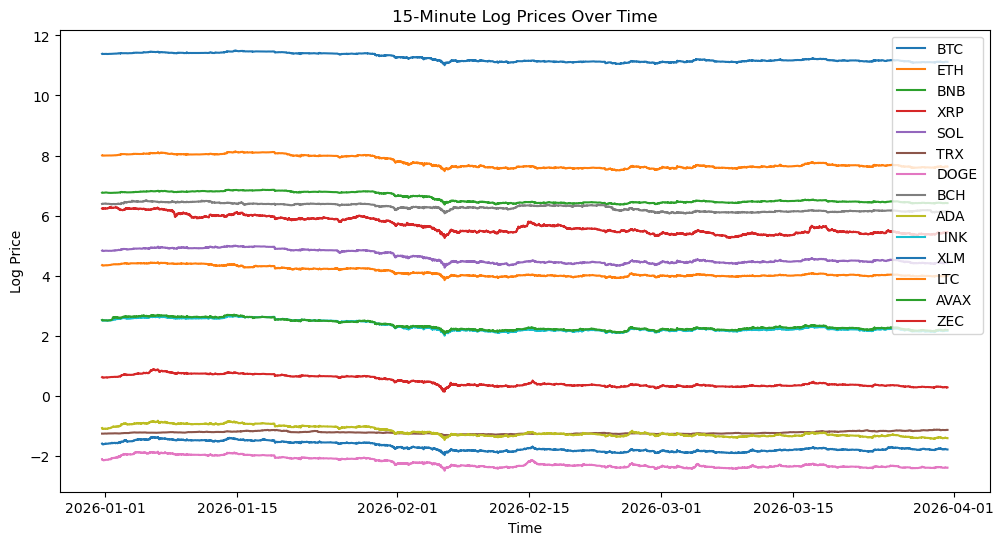

In [59]:
log_df = np.log(df_close_15m)  

plt.figure(figsize=(12, 6))
for col in log_df.columns:
    plt.plot(log_df.index, log_df[col], label=col)
plt.legend()
plt.title("15-Minute Log Prices Over Time")
plt.xlabel("Time")
plt.ylabel("Log Price")

In [60]:
df_close=df_close_15m.copy()

In [61]:
df_close_15m.dropna(inplace=True, axis=0)

In [62]:
df_close_15m

,BTC,ETH,BNB,XRP,SOL,TRX,DOGE,BCH,ADA,LINK,XLM,LTC,AVAX,ZEC
timestamp,,,,,,,,,,,,,,
2025-12-31 16:15:00,87924.21,2987.50,862.27,1.8555,125.36,0.2835,0.12098,594.8,0.3412,12.39,0.2034,77.40,12.45,508.99
2025-12-31 16:30:00,87459.84,2966.70,859.27,1.8463,124.56,0.2838,0.11837,595.3,0.3341,12.27,0.2003,76.94,12.33,506.45
2025-12-31 16:45:00,87656.98,2976.03,861.58,1.8442,124.84,0.2837,0.11900,595.7,0.3336,12.29,0.2002,76.93,12.33,507.76
2025-12-31 17:00:00,87529.99,2970.64,861.82,1.8382,124.66,0.2839,0.11856,596.5,0.3334,12.26,0.1998,76.73,12.33,508.14
2025-12-31 17:15:00,87610.63,2975.40,862.40,1.8422,125.00,0.2836,0.11862,599.6,0.3351,12.28,0.2001,76.74,12.34,510.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-31 07:00:00,67294.69,2051.33,610.68,1.3208,83.06,0.3212,0.09134,468.7,0.2441,8.71,0.1671,53.80,8.92,229.68
2026-03-31 07:15:00,67288.37,2050.47,610.26,1.3160,82.88,0.3213,0.09133,468.6,0.2439,8.69,0.1673,53.78,8.91,229.98
2026-03-31 07:30:00,67323.15,2053.08,610.69,1.3218,82.98,0.3215,0.09143,468.8,0.2439,8.70,0.1672,53.81,8.91,230.91


## Run Cointegration Test
### select BTC related pairs

In [63]:
def test_cointegration_kalman(series_x, series_y, delta=1e-5):
    # Kalman Filter to calculate rolling Alpha and Beta
    state_mean = np.zeros(2) # used to put initial value of alpha and beta
    state_cov = np.ones((2, 2)) # P: Initial uncertainty
    
    Q = (delta / (1 - delta)) * np.eye(2) # Parameter drift
    R = 1.0 # Observation noise
    # Q and R: if Q is large, the filter will adapt quickly to new data, but it will also be more sensitive to noise. 
    # if R is large, the filter will be more conservative and less sensitive to noise.
    # delta: the smaller the delta, the slower the filter will adapt to new data, but it will also be more sensitive to noise.
    
    rolling_alpha = []
    rolling_beta = []
    
    # Iterate through the time series
    for i in range(len(series_x)):
        x_t = series_x.iloc[i]
        y_t = series_y.iloc[i]
        
        H = np.array([[1.0, x_t]])
        
        # Prediction Step
        state_mean_pred = state_mean
        state_cov_pred = state_cov + Q # P: var(theta hat - theta) Variance of theta estimation error: add Q daily: uncertainty
        
        # Update Step
        y_pred = H.dot(state_mean_pred)
        error = y_t - y_pred
        
        S = H.dot(state_cov_pred).dot(H.T) + R # Total confusion var(error) = theta uncertainty + R (observation noise)
        K = state_cov_pred.dot(H.T) / S  # Uncertainty / Total confusion -> Kalman Gain. K ~ P/S
        
        state_mean = state_mean_pred + (K.flatten() * error)
        state_cov = (np.eye(2) - K.dot(H)).dot(state_cov_pred)
        
        rolling_alpha.append(state_mean[0])
        rolling_beta.append(state_mean[1])
        
    rolling_alpha = pd.Series(rolling_alpha, index=series_x.index)
    rolling_beta = pd.Series(rolling_beta, index=series_x.index)

    # Calculate Dynamic Spread
    spread = series_y - (rolling_beta * series_x + rolling_alpha)

    # Stationarity test (ADF) directly on the dynamic spread
    adf_result = adfuller(spread.dropna())
    
    t_stat = adf_result[0]
    pvalue = adf_result[1]
    crit_values = adf_result[4]

    return {
        "latest_beta": rolling_beta.iloc[-1], # Return the most recent beta for the summary table
        "pvalue": pvalue,
        "t_stat": t_stat,
        "crit_1%": crit_values['1%'],
        "crit_5%": crit_values['5%'],
        "crit_10%": crit_values['10%'],
        "spread": spread,
        "rolling_beta_series": rolling_beta # Stored in case you need to plot it later
    }

results = []
pairs = list(combinations(log_df.columns, 2))

for x, y in pairs:
    res = test_cointegration_kalman(log_df[x], log_df[y])

    results.append({
        "pair": f"{x}-{y}",
        "x": x,
        "y": y,
        "latest_beta": res["latest_beta"],
        "pvalue": res["pvalue"],
        "t_stat": res["t_stat"],
        "crit_5%": res["crit_5%"]
    })

df_coint = pd.DataFrame(results)
coint_pairs = df_coint[df_coint["pvalue"] < 0.05]
coint_pairs = coint_pairs.sort_values("pvalue")

# Filter for pairs specifically involving BTC
btc_pairs = coint_pairs[
    (coint_pairs["x"] == "BTC") |
    (coint_pairs["y"] == "BTC")
]

display(btc_pairs)

,pair,x,y,latest_beta,pvalue,t_stat,crit_5%
8,BTC-LINK,BTC,LINK,0.177117,4.104535e-23,-12.422633,-2.861876
0,BTC-ETH,BTC,ETH,0.628290,3.574928e-22,-11.988031,-2.861876
12,BTC-ZEC,BTC,ZEC,0.444109,6.700480e-22,-11.865214,-2.861876
4,BTC-TRX,BTC,TRX,-0.093242,3.287318e-20,-11.130728,-2.861876
6,BTC-BCH,BTC,BCH,0.506185,4.024934e-20,-11.093600,-2.861876
3,BTC-SOL,BTC,SOL,0.363244,5.414178e-20,-11.039382,-2.861876
9,BTC-XLM,BTC,XLM,-0.147956,1.891216e-19,-10.812673,-2.861877
7,BTC-ADA,BTC,ADA,-0.117736,3.188751e-19,-10.718876,-2.861876
10,BTC-LTC,BTC,LTC,0.327157,9.647602e-19,-10.521661,-2.861877
11,BTC-AVAX,BTC,AVAX,0.179007,9.703360e-19,-10.520639,-2.861877


Analyzing the most cointegrated pair: BTC & LINK


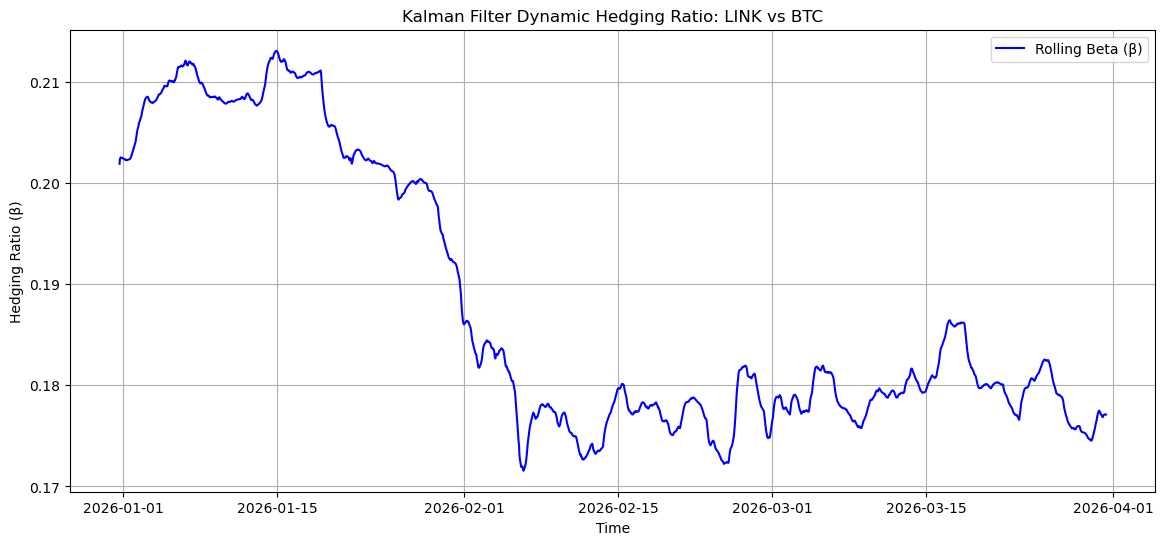

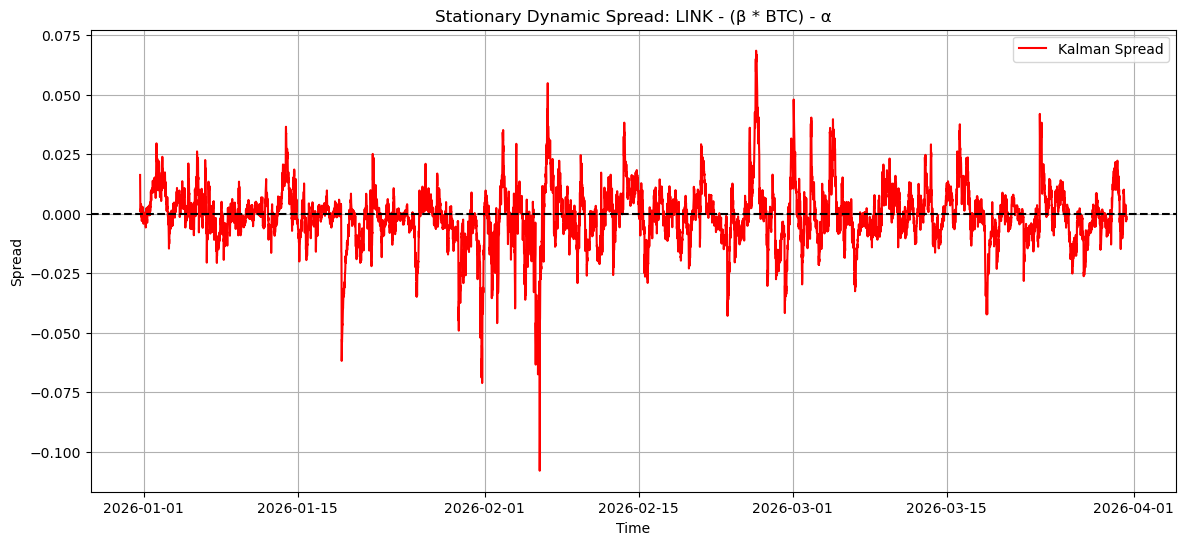

In [64]:
# Select the most cointegrated BTC pair (the one with the lowest p-value)
best_x = btc_pairs.iloc[0]['x']
best_y = btc_pairs.iloc[0]['y']
print(f"Analyzing the most cointegrated pair: {best_x} & {best_y}")

# Re-run the Kalman Filter specifically for this pair to get the full time series
kalman_results = test_cointegration_kalman(log_df[best_x], log_df[best_y])

rolling_beta = kalman_results["rolling_beta_series"]
dynamic_spread = kalman_results["spread"]

# Plot the Dynamic Hedging Ratio (Beta)
plt.figure(figsize=(14, 6))
plt.plot(rolling_beta.index, rolling_beta, label=f'Rolling Beta (\u03b2)', color='blue')
plt.title(f'Kalman Filter Dynamic Hedging Ratio: {best_y} vs {best_x}')
plt.xlabel('Time')
plt.ylabel('Hedging Ratio (\u03b2)')
plt.legend()
plt.grid(True)
plt.show()

# Plot the resulting Dynamic Spread for visualization
plt.figure(figsize=(14, 6))
plt.plot(dynamic_spread.index, dynamic_spread, label='Kalman Spread', color='red')
plt.axhline(0, color='black', linestyle='--', lw=1.5)
plt.title(f'Stationary Dynamic Spread: {best_y} - (\u03b2 * {best_x}) - \u03b1')
plt.xlabel('Time')
plt.ylabel('Spread')
plt.legend()
plt.grid(True)
plt.show()

## Modelling

In [65]:
def build_spread(prices: pd.DataFrame, x: str, y: str, beta: float, use_log=True):
    px = prices[x].astype(float)
    py = prices[y].astype(float)
    if use_log:
        px = np.log(px)
        py = np.log(py)
    spread = py - beta * px
    return spread.dropna()

In [66]:
def fit_ou_from_spread(spread: pd.Series, delta=1.0):
    s = spread.values
    s_t = s[:-1]
    s_t1 = s[1:]

    X = sm.add_constant(s_t)
    res = sm.OLS(s_t1, X).fit()

    b = float(res.params[0])
    a = float(res.params[1])

    if not (0 < a < 1):
        return None  

    eps = res.resid
    lam = -np.log(a) / delta
    mu = b / (1 - a)

    try:
        am = arch_model(pd.Series(s).diff().dropna(), vol='Garch', p=1, q=1, rescale=True)
        garch_res = am.fit(disp='off')
        
        omega = garch_res.params['omega']
        alpha = garch_res.params['alpha[1]']
        beta_p = garch_res.params['beta[1]']
        persist = alpha + beta_p
        

        if persist >= 1.0 or persist <= 0.0:
            raise ValueError("GARCH non-stationary")
            
        sigma = np.sqrt(omega / (1 - persist)) / garch_res.scale
    except:
    
        sigma = float(np.std(eps, ddof=1)) 

    half_life = np.log(2) / lam

    return {
        "a": a, "b": b,
        "lambda": lam,
        "mu": mu,
        "sigma": sigma,
        "half_life": half_life,
        "r2": float(res.rsquared)
    }


In [67]:
def ou_zscore(spread: pd.Series, mu: float, sigma: float):
    return (spread - mu) / sigma

def zscore_signals(z: pd.Series, entry_z=2.5, exit_z=0.5, min_hold=16):
    sig = pd.Series(0, index=z.index, dtype=int)
    current_pos = 0
    bars_held = 0
    
    for i in range(len(z)):
        val = z.iloc[i]
        
        if current_pos == 0:
            if val > entry_z:
                current_pos = -1
                bars_held = 0
            elif val < -entry_z:
                current_pos = 1
                bars_held = 0
        else:
            bars_held += 1
            if bars_held >= min_hold:
                if current_pos == 1 and val >= exit_z:
                    current_pos = 0
                elif current_pos == -1 and val <= -exit_z:
                    current_pos = 0
                    
        sig.iloc[i] = current_pos
        
    return sig

In [68]:
def generate_regime_signals(kalman_spread, window=200, step=5,
                             p_val_threshold=0.1, max_halflife=200):
    results = pd.DataFrame(index=kalman_spread.index)
    results['p_value']       = np.nan
    results['t_stat']        = np.nan
    results['half_life']     = np.nan
    results['regime_signal'] = np.nan

    for i in range(window, len(kalman_spread), step):
        current_spread = kalman_spread.iloc[i - window : i]
        idx = current_spread.index[-1]

        # Rolling ADF test 
        try:
            from statsmodels.tsa.stattools import adfuller
            adf_res        = adfuller(current_spread, maxlag=1, autolag=None)
            p_val, t_stat  = adf_res[1], adf_res[0]
        except Exception as e:
            print(f"ADF error at {idx}: {e}")
            p_val, t_stat  = 1.0, 0.0

        results.loc[idx, 'p_value'] = p_val
        results.loc[idx, 't_stat']  = t_stat
        try:
            y        = current_spread.values
            y_lag    = y[:-1]
            delta_y  = y[1:] - y_lag
            lam      = sm.OLS(delta_y, sm.add_constant(y_lag)).fit().params[1]
            half_life = -np.log(2) / lam if lam < 0 else np.inf
        except Exception as e:
            print(f"Half-life error at {idx}: {e}")
            half_life = np.inf

        results.loc[idx, 'half_life'] = half_life

        # Regime rule
        if (p_val < p_val_threshold) and (0 < half_life < max_halflife):
            results.loc[idx, 'regime_signal'] = 1   # green – allow trading
        else:
            results.loc[idx, 'regime_signal'] = 0   # red   – halt trading

    # Forward-fill between computation steps; default to 0 (red) at the start
    results['regime_signal'] = (
        results['regime_signal']
        .ffill()
        .fillna(0)
        .astype(int)
    )
    return results

In [69]:
def walk_forward_signals(prices, x, y, train_window, trade_window):
    signals = []
    z_scores = []

    for start in range(train_window, len(prices) - trade_window, trade_window):
        train = prices.iloc[start - train_window:start]
        test  = prices.iloc[start:start + trade_window]

        # Obtain Kalman beta from training window 
        # test_cointegration_kalman returns a dict with 'latest_beta'
        kalman_res = test_cointegration_kalman(train[x], train[y])
        beta = kalman_res["latest_beta"]   # float, final hedge ratio

        # Build spread using this beta
        spread_train = train[y] - beta * train[x]

        # Fit OU process to the spread
        ou = fit_ou_from_spread(spread_train)
        if ou is None:
            continue

        # Compute z‑score on test window
        spread_test = test[y] - beta * test[x]
        z = ou_zscore(spread_test, ou["mu"], ou["sigma"])

        # Generate trading signals
        sig = zscore_signals(z, entry_z=2.0, exit_z=0.0) 


        signals.append(sig)
        z_scores.append(z)

    if not signals:
        return pd.Series(dtype=float), pd.Series(dtype=int)

    signals = pd.concat(signals)
    z_scores = pd.concat(z_scores)
    return z_scores, signals

In [72]:
def walk_forward_dynamic_btc_pairs(prices, train_window=24*4*25, trade_window=24*4, pvalue_threshold=0.05, max_halflife=24*4*2):
    log_prices = np.log(prices)
    cols = log_prices.columns.tolist()
    pair_data = {}
    
    print("Pre-calculating global Kalman filters...")
    kf_results = {}
    for other in cols:
        if other == "BTC":
            continue
        x, y = "BTC", other
        pair_str = f"{x}-{y}"
        kf_results[pair_str] = test_cointegration_kalman(log_prices[x], log_prices[y])

    # Walk-forward loop
    for start in range(train_window, len(log_prices) - trade_window, trade_window):
        for other in cols:
            if other == "BTC":
                continue

            x, y = "BTC", other
            pair_str = f"{x}-{y}"

            kf_res = kf_results[pair_str]
            spread_full = kf_res["spread"]
            beta_full = kf_res["rolling_beta_series"]

            spread_train = spread_full.iloc[start - train_window : start]
            spread_test  = spread_full.iloc[start : start + trade_window]

            from statsmodels.tsa.stattools import adfuller
            adf_result = adfuller(spread_train.dropna())
            pvalue = adf_result[1]
            if pvalue >= pvalue_threshold:
                continue  

            ou = fit_ou_from_spread(spread_train)
            if ou is None:
                continue

            if not (0 < ou["half_life"] < max_halflife):
                continue
            
            # If both regimes pass, issue signal on test using current parameters to calculate z-score
            z = ou_zscore(spread_test, ou["mu"], ou["sigma"])
            lookback = max(10, len(z) // 4)
            sig = zscore_signals(z, entry_z=2.5, exit_z=0, min_hold = 16)

            if pair_str not in pair_data:
                pair_data[pair_str] = {"signals": [], "z_scores": [], "beta": []}

            pair_data[pair_str]["signals"].append(sig)
            pair_data[pair_str]["z_scores"].append(z)
            # Store the true dynamic Beta list at this moment
            pair_data[pair_str]["beta"].append(beta_full.iloc[start : start + trade_window])

    results = []
    for pair_str, data in pair_data.items():
        if not data["signals"]:
            continue
        results.append({
            "pair":     pair_str,
            "beta":     pd.concat(data["beta"]),
            "z_scores": pd.concat(data["z_scores"]),
            "signal":   pd.concat(data["signals"])
        })

    return results

In [73]:
ou_results = walk_forward_dynamic_btc_pairs(df_close_15m)
print(f"Dynamic pair selection found {len(ou_results)} BTC pairs with cointegration signal")
for r in ou_results:
    print(f"  {r['pair']}: {len(r['signal'])} signal bars")

Pre-calculating global Kalman filters...
Dynamic pair selection found 13 BTC pairs with cointegration signal
  BTC-ETH: 6144 signal bars
  BTC-BNB: 6144 signal bars
  BTC-XRP: 6144 signal bars
  BTC-SOL: 6144 signal bars
  BTC-TRX: 6144 signal bars
  BTC-DOGE: 6144 signal bars
  BTC-BCH: 6144 signal bars
  BTC-ADA: 6144 signal bars
  BTC-LINK: 6144 signal bars
  BTC-XLM: 6144 signal bars
  BTC-LTC: 6144 signal bars
  BTC-AVAX: 6144 signal bars
  BTC-ZEC: 6144 signal bars


In [ ]:
ou_results

[{'pair': 'BTC-ETH',
  'beta': timestamp
  2026-01-25 13:00:00    0.644350
  2026-01-25 13:15:00    0.644345
  2026-01-25 13:30:00    0.644342
  2026-01-25 13:45:00    0.644337
  2026-01-25 14:00:00    0.644330
                           ...   
  2026-03-30 11:45:00    0.627786
  2026-03-30 12:00:00    0.627819
  2026-03-30 12:15:00    0.627848
  2026-03-30 12:30:00    0.627880
  2026-03-30 12:45:00    0.627910
  Length: 6144, dtype: float64,
  'z_scores': timestamp
  2026-01-25 13:00:00   -0.316809
  2026-01-25 13:15:00   -0.751857
  2026-01-25 13:30:00   -0.297633
  2026-01-25 13:45:00   -0.575019
  2026-01-25 14:00:00   -1.043699
                           ...   
  2026-03-30 11:45:00    5.586444
  2026-03-30 12:00:00    4.962796
  2026-03-30 12:15:00    4.318526
  2026-03-30 12:30:00    4.859553
  2026-03-30 12:45:00    4.674290
  Length: 6144, dtype: float64,
  'signal': timestamp
  2026-01-25 13:00:00    0
  2026-01-25 13:15:00    0
  2026-01-25 13:30:00    0
  2026-01-25 13:45:0

In [ ]:
ou_df = pd.DataFrame([
    {
        "pair": r["pair"],
        "beta": r["beta"],
        "z_scores": r["z_scores"]
        
    }
    for r in ou_results
])


In [ ]:
signals_df = pd.concat(
    {r["pair"]: r["signal"] for r in ou_results},
    axis=1
).sort_index()

In [ ]:
signals_df

,BTC-ETH,BTC-BNB,BTC-XRP,BTC-SOL,BTC-TRX,BTC-DOGE,BTC-BCH,BTC-ADA,BTC-LINK,BTC-XLM,BTC-LTC,BTC-AVAX,BTC-ZEC
timestamp,,,,,,,,,,,,,
2026-01-25 13:00:00,0,0,0,0,0,0,0,0,0,0,-1,0,0
2026-01-25 13:15:00,0,0,0,0,0,0,0,0,0,0,-1,0,0
2026-01-25 13:30:00,0,0,0,0,-1,0,0,0,0,0,-1,0,0
2026-01-25 13:45:00,0,0,0,0,-1,0,0,0,0,0,-1,0,0
2026-01-25 14:00:00,0,0,0,0,-1,0,0,0,0,0,-1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-30 11:45:00,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,-1,-1
2026-03-30 12:00:00,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,0,-1,-1
2026-03-30 12:15:00,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,1,-1,-1


In [ ]:
print(signals_df.describe())
print("\nSignal distribution for each pair:")
for col in signals_df.columns:
    print(f"{col}: {signals_df[col].value_counts().to_dict()}")


           BTC-ETH      BTC-BNB      BTC-XRP      BTC-SOL      BTC-TRX  \
count  6144.000000  6144.000000  6144.000000  6144.000000  6144.000000   
mean      0.029622    -0.025065     0.025879     0.031087    -0.075195   
std       0.770045     0.755051     0.687187     0.776828     0.859233   
min      -1.000000    -1.000000    -1.000000    -1.000000    -1.000000   
25%      -1.000000    -1.000000     0.000000    -1.000000    -1.000000   
50%       0.000000     0.000000     0.000000     0.000000     0.000000   
75%       1.000000     1.000000     0.000000     1.000000     1.000000   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

          BTC-DOGE      BTC-BCH      BTC-ADA     BTC-LINK      BTC-XLM  \
count  6144.000000  6144.000000  6144.000000  6144.000000  6144.000000   
mean      0.026855    -0.108073     0.040690    -0.015951     0.003906   
std       0.727203     0.725373     0.788348     0.785100     0.753515   
min      -1.000000    -1.000000    -1

In [ ]:
# performance metrics
def _max_drawdown(equity: pd.Series) -> float:
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min())

def _sharpe(returns: pd.Series, bars_per_year: int) -> float:
    r = returns.dropna()
    if len(r) < 2:
        return np.nan
    mu = r.mean()
    sd = r.std(ddof=1)
    if sd == 0:
        return np.nan
    return float((mu / sd) * np.sqrt(bars_per_year))

def _trade_stats(signal: pd.Series, pnl: pd.Series):
    s = signal.fillna(0).astype(int)
    pnl = pnl.fillna(0.0)

    changes = s.diff().fillna(s.iloc[0]).astype(int)

    entry_idx = s[(s != 0) & (changes != 0)].index
    exit_idx = s[(s == 0) & (changes != 0)].index

    episodes = []
    for ei in entry_idx:
        exits_after = exit_idx[exit_idx > ei]
        if len(exits_after) == 0:
            break
        xo = exits_after[0]
        ep_pnl = pnl.loc[ei:xo].sum()
        episodes.append(ep_pnl)

    if len(episodes) == 0:
        return {
            "num_trades": 0,
            "win_rate": np.nan,
            "avg_trade_pnl": np.nan,
            "median_trade_pnl": np.nan,
            "profit_factor": np.nan,
        }

    ep = np.array(episodes, dtype=float)
    wins = ep[ep > 0]
    losses = ep[ep < 0]

    profit_factor = np.nan
    if losses.size > 0:
        profit_factor = wins.sum() / (-losses.sum()) if wins.size > 0 else 0.0

    return {
        "num_trades": int(len(ep)),
        "win_rate": float((ep > 0).mean()),
        "avg_trade_pnl": float(ep.mean()),
        "median_trade_pnl": float(np.median(ep)),
        "profit_factor": float(profit_factor) if not np.isnan(profit_factor) else np.nan,
    }

In [ ]:
def backtest_pair_perps(
    prices: pd.DataFrame,
    x: str,
    y: str,
    beta,                           
    signal: pd.Series,
    initial_capital: float = 10_000.0,
    leverage: float = 3.0,
    alloc: float = 1.0,                 
    fee_rate: float = 0.0004,           
    slippage_bps: float = 1.0,          
    bars_per_year: int = 365 * 24 * 4,  
    allow_flip_same_bar: bool = True,
) -> dict:

    px = prices[x].astype(float).copy()
    py = prices[y].astype(float).copy()

    if isinstance(beta, pd.Series):
        df = pd.concat([px.rename("px"), py.rename("py"), signal.rename("sig"), beta.rename("beta")], axis=1).dropna()
    else:
        df = pd.concat([px.rename("px"), py.rename("py"), signal.rename("sig")], axis=1).dropna()
        df["beta"] = float(beta)
        
    df["sig"] = df["sig"].astype(int)

    if len(df) < 5:
        return {"pair": f"{x}-{y}", "df": df, "stats": {"error": "not enough data"}}

    equity = np.zeros(len(df), dtype=float)
    pnl = np.zeros(len(df), dtype=float)
    fees = np.zeros(len(df), dtype=float)

    ux = np.zeros(len(df), dtype=float)
    uy = np.zeros(len(df), dtype=float)

    equity[0] = initial_capital
    prev_sig = 0
    prev_ux = 0.0
    prev_uy = 0.0

    for i in range(1, len(df)):
        px_prev, py_prev = float(df["px"].iloc[i - 1]), float(df["py"].iloc[i - 1])
        px_now,  py_now  = float(df["px"].iloc[i]),     float(df["py"].iloc[i])
        sig_now = int(df["sig"].iloc[i])
        
        beta_now = float(df["beta"].iloc[i]) 
        w_x = abs(beta_now)
        w_y = 1.0
        denom = (w_x + w_y) if (w_x + w_y) != 0 else 1.0

        mtm = prev_ux * (px_now - px_prev) + prev_uy * (py_now - py_prev)
        pnl[i] = mtm
        equity[i] = equity[i - 1] + mtm

        gross = max(equity[i], 0.0) * float(alloc) * float(leverage)
        ny = gross * (w_y / denom)
        nx = gross * (w_x / denom)

        if sig_now == 0:
            tgt_ux, tgt_uy = 0.0, 0.0
        elif sig_now == 1:
            tgt_uy = + (ny / py_now)
            tgt_ux = - np.sign(beta_now) * (nx / px_now)
        else:  
            tgt_uy = - (ny / py_now)
            tgt_ux = + np.sign(beta_now) * (nx / px_now)

        changed = (sig_now != prev_sig)
        if changed and (not allow_flip_same_bar) and (prev_sig != 0) and (sig_now != 0):
            tgt_ux, tgt_uy = 0.0, 0.0

        dx = tgt_ux - prev_ux
        dy = tgt_uy - prev_uy
        traded_notional = abs(dx) * px_now + abs(dy) * py_now
        cost = traded_notional * (fee_rate + (slippage_bps / 10_000.0))

        fees[i] = cost
        equity[i] -= cost  

        ux[i] = tgt_ux
        uy[i] = tgt_uy
        prev_ux, prev_uy = tgt_ux, tgt_uy
        prev_sig = sig_now

    out = df.copy()
    out["ux"] = ux
    out["uy"] = uy
    out["pnl"] = pnl
    out["fees"] = fees
    out["equity"] = equity
    out["ret"] = out["equity"].pct_change().fillna(0.0)

    traded = (out["ux"].diff().abs() * out["px"] + out["uy"].diff().abs() * out["py"]).fillna(0.0)
    out["turnover"] = traded / out["equity"].replace(0, np.nan)

    final_beta = float(df["beta"].iloc[-1])

    stats = {
        "pair": f"{x}-{y}",
        "beta": final_beta,
        "initial_capital": float(initial_capital),
        "final_equity": float(out["equity"].iloc[-1]),
        "total_pnl": float(out["pnl"].sum() - out["fees"].sum()),
        "gross_pnl": float(out["pnl"].sum()),
        "total_fees": float(out["fees"].sum()),
        "sharpe": _sharpe(out["ret"], bars_per_year=bars_per_year),
        "max_drawdown": _max_drawdown(out["equity"]),
        "avg_turnover": float(out["turnover"].replace([np.inf, -np.inf], np.nan).dropna().mean()) if out["turnover"].notna().any() else np.nan,
    }
    stats.update(_trade_stats(out["sig"], out["pnl"] - out["fees"]))

    return {"pair": f"{x}-{y}", "df": out, "stats": stats}


In [ ]:
all_stats = []
bt_results = {}

for r in ou_results:
    pair = r["pair"]     
    beta = r["beta"]
    sig = r["signal"]      
    x, y = pair.split("-")
    res = backtest_pair_perps(
        prices=df_close_15m,
        x=x, y=y,
        beta=beta,
        signal=sig,
        initial_capital=10_000,
        leverage=3.0,
        alloc=1,
        fee_rate=0.0004,
        slippage_bps=1.0,
        bars_per_year=365*24*4,  
    )

    bt_results[pair] = res
    all_stats.append(res["stats"])

stats_df = pd.DataFrame(all_stats).sort_values("sharpe", ascending=False)
stats_df

,pair,beta,initial_capital,final_equity,total_pnl,gross_pnl,total_fees,sharpe,max_drawdown,avg_turnover,num_trades,win_rate,avg_trade_pnl,median_trade_pnl,profit_factor
10,BTC-LTC,0.327374,10000.0,10790.883889,790.883889,3979.388438,3188.504550,0.937793,-0.279477,0.104937,100,0.630000,6.451672,54.673526,1.068603
9,BTC-XLM,-0.147332,10000.0,5458.249076,-4541.750924,-1841.573298,2700.177625,-0.846822,-0.564542,0.109400,97,0.567010,-41.781050,74.422397,0.793311
11,BTC-AVAX,0.178476,10000.0,5760.601102,-4239.398898,-1691.654635,2547.744262,-1.247898,-0.467134,0.105627,95,0.642105,-42.870453,91.408146,0.763947
2,BTC-XRP,0.022944,10000.0,3253.439922,-6746.560078,-5642.385917,1104.174161,-2.487348,-0.748577,0.086414,76,0.578947,-87.764137,11.295889,0.426415
7,BTC-ADA,-0.117204,10000.0,2806.012338,-7193.987662,-5314.837576,1879.150085,-2.513567,-0.724830,0.106157,92,0.565217,-75.367628,29.155033,0.599465
3,BTC-SOL,0.363528,10000.0,4104.737270,-5895.262730,-3987.598581,1907.664149,-3.380669,-0.619483,0.102706,95,0.515789,-61.057700,13.844529,0.520809
1,BTC-BNB,0.528935,10000.0,7162.029344,-2837.970656,-526.172977,2311.797679,-3.495072,-0.327101,0.097061,94,0.414894,-30.738909,-13.327232,0.521132
8,BTC-LINK,0.176858,10000.0,2779.718270,-7220.281730,-5618.151600,1602.130130,-3.648271,-0.744010,0.103896,93,0.473118,-75.341340,-6.188331,0.423667
12,BTC-ZEC,0.442464,10000.0,2144.472525,-7855.527475,-6089.009154,1766.518321,-3.765782,-0.818810,0.124910,111,0.621622,-71.039461,31.725037,0.554328
5,BTC-DOGE,-0.198103,10000.0,1873.444230,-8126.555770,-6928.901991,1197.653779,-4.148700,-0.855090,0.089142,77,0.571429,-103.484916,13.707434,0.446865


In [ ]:
print(f"Total PnL: {stats_df['total_pnl'].sum()}")

Total PnL: -69956.53812511318


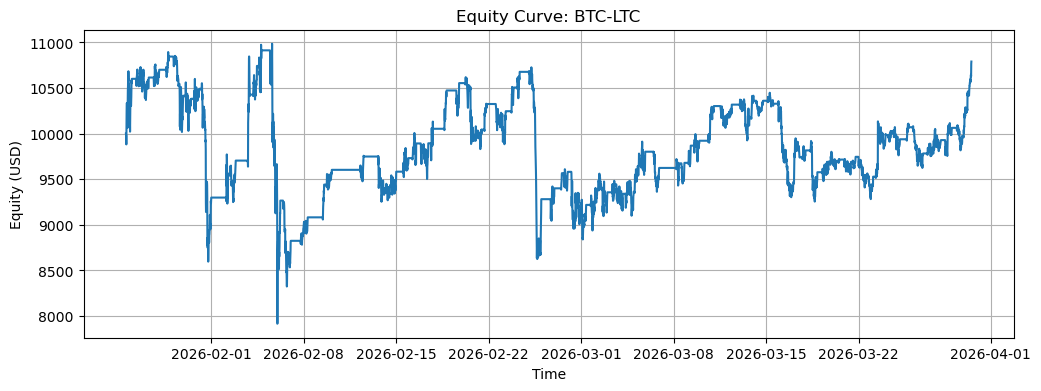

{'pair': 'BTC-LTC',
 'beta': 0.3273742239899226,
 'initial_capital': 10000.0,
 'final_equity': 10790.883888543913,
 'total_pnl': 790.883888543905,
 'gross_pnl': 3979.3884383971686,
 'total_fees': 3188.5045498532636,
 'sharpe': 0.9377926236847914,
 'max_drawdown': -0.2794767513218348,
 'avg_turnover': 0.10493713281680904,
 'num_trades': 100,
 'win_rate': 0.63,
 'avg_trade_pnl': 6.451672157364678,
 'median_trade_pnl': 54.67352627111127,
 'profit_factor': 1.0686027070386}

In [ ]:
best_pair = stats_df.iloc[0]["pair"]
eq = bt_results[best_pair]["df"]["equity"]

plt.figure(figsize=(12,4))
plt.plot(eq.index, eq.values)
plt.title(f"Equity Curve: {best_pair}")
plt.xlabel("Time")
plt.ylabel("Equity (USD)")
plt.grid(True)
plt.show()

bt_results[best_pair]["stats"]

Regime Filter – Backtest Comparison
Compare P&L **with** vs **without** regime detection across all BTC pairs.

Running regime detection on BTC-LINK spread (8608 bars)...


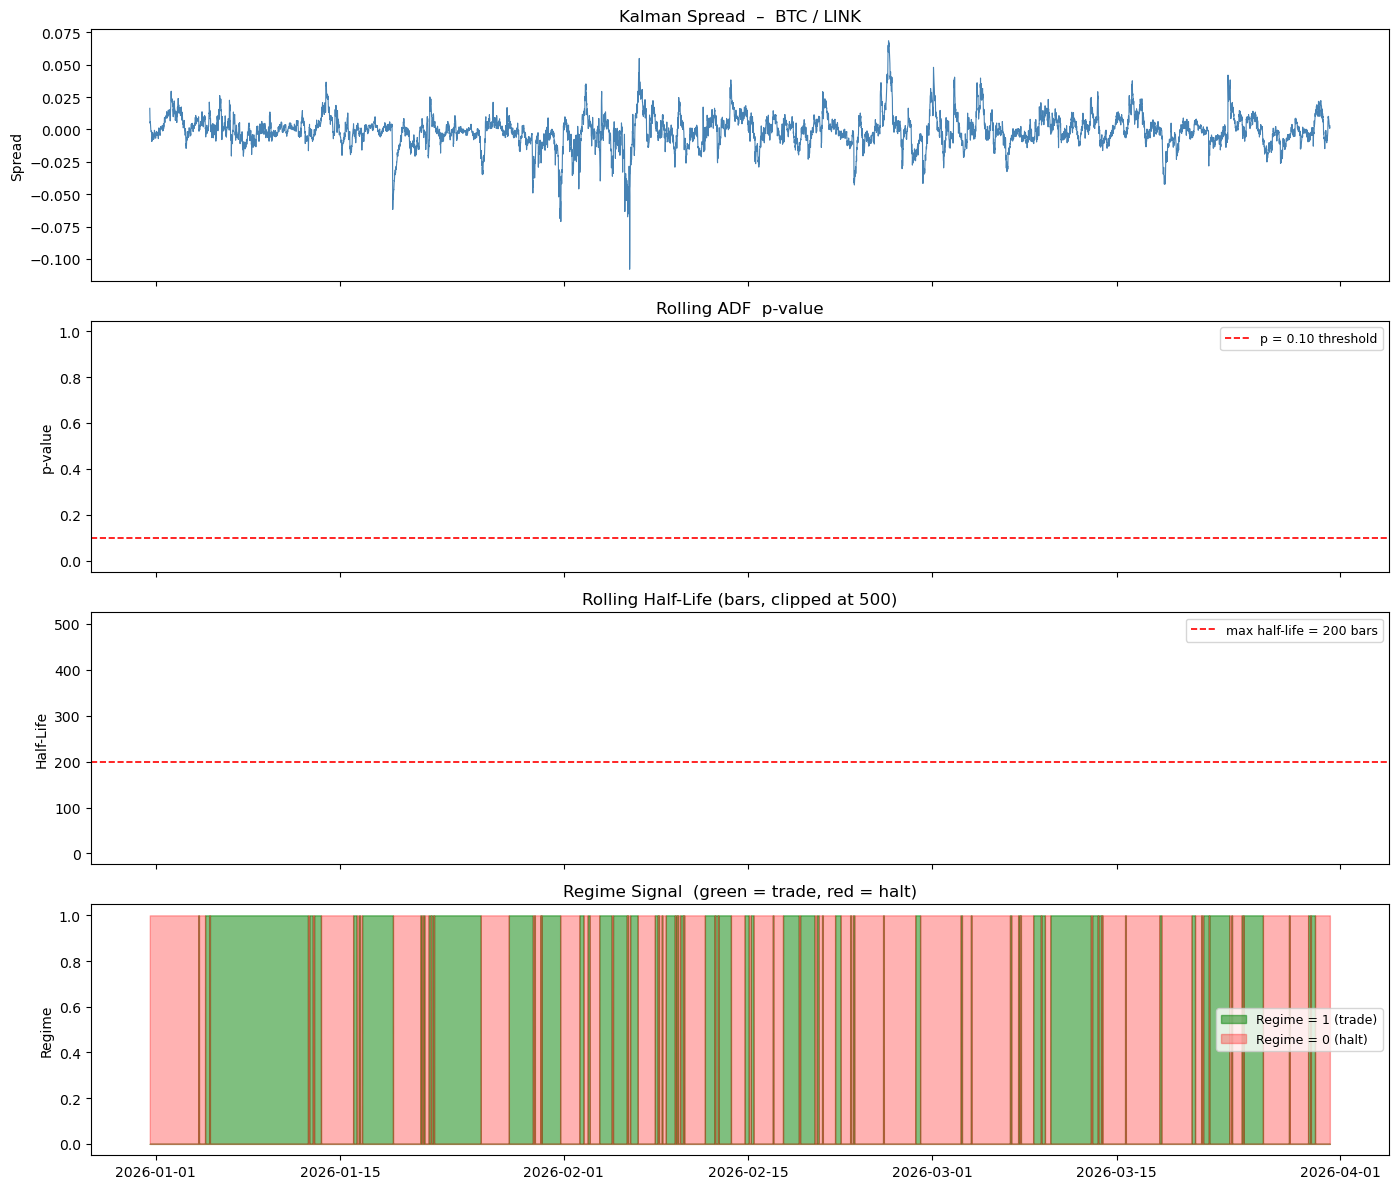


Time allowed to trade: 43.2%


In [ ]:
# Visualise rolling regime diagnostics for the best pair
best_pair_x = btc_pairs.iloc[0]['x']
best_pair_y = btc_pairs.iloc[0]['y']

kalman_res_best   = test_cointegration_kalman(log_df[best_pair_x], log_df[best_pair_y])
kalman_spread_best = kalman_res_best["spread"]

print(f"Running regime detection on {best_pair_x}-{best_pair_y} spread ({len(kalman_spread_best)} bars)...")
regime_df_best = generate_regime_signals(kalman_spread_best)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(kalman_spread_best.index, kalman_spread_best, color='steelblue', lw=0.8)
axes[0].set_title(f'Kalman Spread  –  {best_pair_x} / {best_pair_y}')
axes[0].set_ylabel('Spread')

axes[1].plot(regime_df_best.index, regime_df_best['p_value'], color='darkorange', lw=0.8)
axes[1].axhline(0.1, color='red', linestyle='--', lw=1.2, label='p = 0.10 threshold')
axes[1].set_title('Rolling ADF  p-value')
axes[1].set_ylabel('p-value')
axes[1].legend(fontsize=9)

axes[2].plot(regime_df_best.index, regime_df_best['half_life'].clip(upper=500),
             color='purple', lw=0.8)
axes[2].axhline(200, color='red', linestyle='--', lw=1.2, label='max half-life = 200 bars')
axes[2].set_title('Rolling Half-Life (bars, clipped at 500)')
axes[2].set_ylabel('Half-Life')
axes[2].legend(fontsize=9)

axes[3].fill_between(regime_df_best.index, regime_df_best['regime_signal'],
                     color='green', alpha=0.5, label='Regime = 1 (trade)')
axes[3].fill_between(regime_df_best.index,
                     (regime_df_best['regime_signal'] == 0).astype(int),
                     color='red', alpha=0.3, label='Regime = 0 (halt)')
axes[3].set_title('Regime Signal  (green = trade, red = halt)')
axes[3].set_ylabel('Regime')
axes[3].legend(fontsize=9)

plt.tight_layout()
plt.show()

pct_green = regime_df_best['regime_signal'].mean() * 100
print(f"\nTime allowed to trade: {pct_green:.1f}%")

In [ ]:
# Run backtest WITH integrated regime filter for all BTC pairs
all_stats_with_regime = []
bt_with_regime = {}

for r in ou_results:
    pair = r["pair"]
    beta = r["beta"]
    sig  = r["signal"]
    x, y = pair.split("-")

    # Backtest WITH regime (Signals have been directly filtered during the rolling process)
    res_w = backtest_pair_perps(
        prices=df_close_15m, x=x, y=y, beta=beta, signal=sig,
        initial_capital=10_000, leverage=3.0, alloc=1,
        fee_rate=0.0004, slippage_bps=1.0, bars_per_year=365*24*4,
    )
    bt_with_regime[pair] = res_w
    all_stats_with_regime.append(res_w["stats"])

cols = ["sharpe", "max_drawdown", "total_pnl", "num_trades", "win_rate"]

df_stats = (pd.DataFrame(all_stats_with_regime)
           .set_index("pair")[cols]
           .sort_values("sharpe", ascending=False))

print("=== Regime Filtered Backtest Results ===")
display(df_stats)

=== Regime Filtered Backtest Results ===


,sharpe,max_drawdown,total_pnl,num_trades,win_rate
pair,,,,,
BTC-LTC,0.937793,-0.279477,790.883889,100,0.630000
BTC-XLM,-0.846822,-0.564542,-4541.750924,97,0.567010
BTC-AVAX,-1.247898,-0.467134,-4239.398898,95,0.642105
BTC-XRP,-2.487348,-0.748577,-6746.560078,76,0.578947
BTC-ADA,-2.513567,-0.724830,-7193.987662,92,0.565217
BTC-SOL,-3.380669,-0.619483,-5895.262730,95,0.515789
BTC-BNB,-3.495072,-0.327101,-2837.970656,94,0.414894
BTC-LINK,-3.648271,-0.744010,-7220.281730,93,0.473118
BTC-ZEC,-3.765782,-0.818810,-7855.527475,111,0.621622


In [ ]:
def build_trade_log(bt_df: pd.DataFrame):

    trades = []
    position = 0
    entry_time = None
    entry_px = None
    entry_py = None

    for i in range(1, len(bt_df)):

        sig_prev = bt_df["sig"].iloc[i-1]
        sig_now  = bt_df["sig"].iloc[i]

        px = bt_df["px"].iloc[i]
        py = bt_df["py"].iloc[i]
        time = bt_df.index[i]

        # ENTRY
        if position == 0 and sig_now != 0:
            position = sig_now
            entry_time = time
            entry_px = px
            entry_py = py

        # EXIT
        elif position != 0 and sig_now == 0:

            exit_time = time
            exit_px = px
            exit_py = py

            pnl = bt_df.loc[entry_time:exit_time, "pnl"].sum() \
                  - bt_df.loc[entry_time:exit_time, "fees"].sum()

            trades.append({
                "entry_time": entry_time,
                "exit_time": exit_time,
                "direction": "long_spread" if position == 1 else "short_spread",
                "entry_px_x": entry_px,
                "entry_px_y": entry_py,
                "exit_px_x": exit_px,
                "exit_px_y": exit_py,
                "holding_minutes": (exit_time - entry_time).total_seconds() / 60,
                "pnl": pnl
            })

            position = 0
            entry_time = None

        # FLIP POSITION
        elif position != 0 and sig_now == -position:

            exit_time = time
            exit_px = px
            exit_py = py

            pnl = bt_df.loc[entry_time:exit_time, "pnl"].sum() \
                  - bt_df.loc[entry_time:exit_time, "fees"].sum()

            trades.append({
                "entry_time": entry_time,
                "exit_time": exit_time,
                "direction": "long_spread" if position == 1 else "short_spread",
                "entry_px_x": entry_px,
                "entry_px_y": entry_py,
                "exit_px_x": exit_px,
                "exit_px_y": exit_py,
                "holding_minutes": (exit_time - entry_time).total_seconds() / 60,
                "pnl": pnl
            })

            # new position
            position = sig_now
            entry_time = time
            entry_px = px
            entry_py = py

    return pd.DataFrame(trades)

In [ ]:
pair = "BTC-LTC"

bt_df = bt_results[pair]["df"]

trade_log = build_trade_log(bt_df)

trade_log

,entry_time,exit_time,direction,entry_px_x,entry_px_y,exit_px_x,exit_px_y,holding_minutes,pnl
0,2026-01-25 13:15:00,2026-01-25 17:00:00,short_spread,88697.45,69.85,87863.05,67.69,225.0,601.675283
1,2026-01-25 17:15:00,2026-01-25 23:45:00,long_spread,87888.60,67.51,86670.36,67.30,390.0,-0.143532
2,2026-01-26 07:45:00,2026-01-26 13:00:00,short_spread,88000.64,68.39,87829.84,68.41,315.0,-58.171825
3,2026-01-26 14:30:00,2026-01-27 06:30:00,short_spread,88144.09,69.57,88285.71,69.24,960.0,72.373124
4,2026-01-27 15:30:00,2026-01-28 01:15:00,short_spread,87701.38,69.69,89327.68,69.76,585.0,84.997038
...,...,...,...,...,...,...,...,...,...
95,2026-03-28 18:00:00,2026-03-29 01:15:00,long_spread,66939.21,53.97,66550.33,54.09,435.0,62.653957
96,2026-03-29 10:15:00,2026-03-29 20:45:00,long_spread,66468.21,53.75,66614.05,53.65,630.0,-90.284848
97,2026-03-29 22:30:00,2026-03-30 02:30:00,long_spread,65684.25,52.95,67038.75,54.02,240.0,272.961490
98,2026-03-30 02:45:00,2026-03-30 06:45:00,short_spread,67121.01,54.09,67305.14,53.62,240.0,189.821055


# Revised pair-trading strategy (explicit walk-forward optimization)

This section replaces the earlier walk-forward logic with a cleaner version that makes the optimization step explicit:

1. **Train window only**
   - fit the Kalman hedge ratio on the training sample
   - test the spread for stationarity on the training sample
   - fit OU parameters on the training sample
   - grid-search signal parameters on the training sample only

2. **Test window only**
   - freeze the chosen parameters from the training window
   - generate out-of-sample signals on the next test window
   - concatenate all test windows to form the final out-of-sample strategy

Key fixes versus the earlier implementation:
- removes the global pre-calculated Kalman filter that leaked future information
- makes parameter optimization explicit and window-by-window
- lags execution by one bar in the backtest to avoid same-bar lookahead
- stores a per-window summary so you can show your supervisor exactly what was optimized and when
